## ResNet-18 Model Pneumonia CXR Synthetic Data Training


🚀 Epoch 1/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 2/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 3/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 4/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 5/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.5000

🚀 Epoch 6/30
Alignment: 1.0000
Val Accuracy: 0.6250, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 7/30
Alignment: 1.0000
Val Accuracy: 0.6250, Val F1: 0.6667

🚀 Epoch 8/30
Alignment: 1.0000
Val Accuracy: 0.6250, Val F1: 0.6667

🚀 Epoch 9/30
Alignment: 1.0000
Val Accuracy: 0.6875, Val F1: 0.7619
✅ Saved new best model!

🚀 Epoch 10/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6000

🚀 Epoch 11/30
Alignment: 1.0000
Val Accuracy: 0.4375, Val F1: 0.4706

🚀 Epoch 12/30
Alignment: 1.0000
Val Accuracy: 0.6250, Val F1: 0.5000

🚀 Epoch 13/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.0000

🚀 Epoch 14/30
Alignment: 1

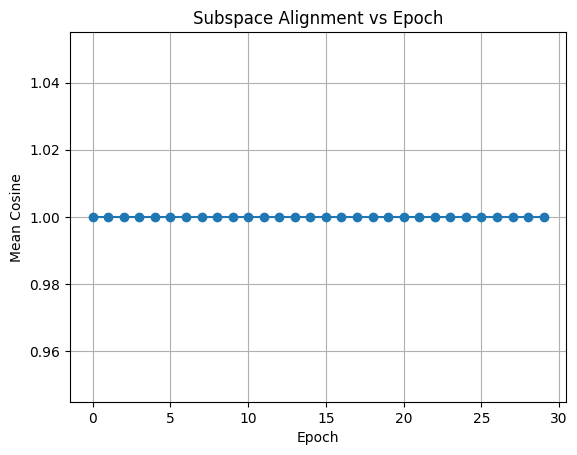

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "resnet18",
    "epochs": 30,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\synthetic_data\NORMAL",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\synthetic_data\PNEUMONIA",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\val_data\NORMAL",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\val_data\PNEUMONIA",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\test_data\NORMAL",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\test_data\PNEUMONIA",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\pneumonia_cxr\resnet18.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_pneumonia_cxr_resnet18.png"
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), # Small rotations to mimic slight patient tilt
    transforms.RandomAffine(
        degrees=0, 
        translate=(0.1, 0.1), 
        scale=(0.9, 1.1)
    ), # Zoom and shift
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Mimic different X-ray exposures
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard ImageNet normalization
])

val_test_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], train_transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], train_transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], val_test_transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], val_test_transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], val_test_transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], val_test_transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")


# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()

## MobilenetV2 Model Pneumonia Synthetic Data training


🚀 Epoch 1/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 2/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 3/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 4/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 5/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 6/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 7/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 8/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 9/30
Alignment: 1.0000
Val Accuracy: 0.6250, Val F1: 0.7273
✅ Saved new best model!

🚀 Epoch 10/30
Alignment: 1.0000
Val Accuracy: 0.6250, Val F1: 0.4000

🚀 Epoch 11/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.5000

🚀 Epoch 12/30
Alignment: 1.0000
Val Accuracy: 0.6875, Val F1: 0.7368
✅ Saved new best model!

🚀 Epoch 13/30
Alignment: 1.0000
Val Accuracy: 0.6250, Val F1: 0.5714

🚀 Epoch 14/30
Alignment: 1

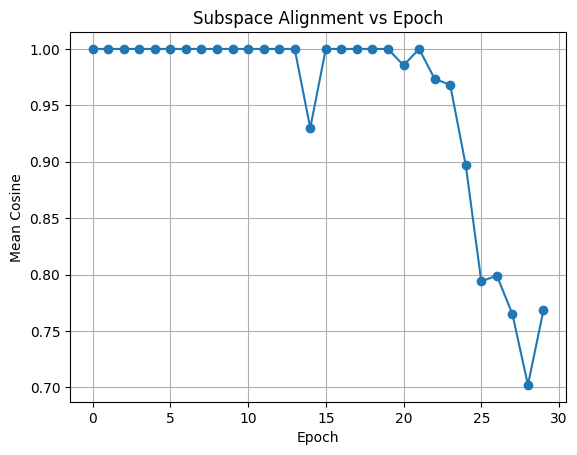

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "mobilenetv2",
    "epochs": 30,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\synthetic_data\NORMAL",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\synthetic_data\PNEUMONIA",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\val_data\NORMAL",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\val_data\PNEUMONIA",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\test_data\NORMAL",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\test_data\PNEUMONIA",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\mobilenetv2.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_mobilenetv2.png"
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), # Small rotations to mimic slight patient tilt
    transforms.RandomAffine(
        degrees=0, 
        translate=(0.1, 0.1), 
        scale=(0.9, 1.1)
    ), # Zoom and shift
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Mimic different X-ray exposures
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard ImageNet normalization
])

val_test_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], train_transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], train_transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], val_test_transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], val_test_transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], val_test_transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], val_test_transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")


# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()

## EfficientNetB0 Model Pneumonia Synthetic Data training


🚀 Epoch 1/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 2/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 3/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 4/30
Alignment: 0.2480
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 5/30
Alignment: 0.2059
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 6/30
Alignment: 0.2152
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 7/30
Alignment: 0.2744
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 8/30
Alignment: 0.3217
Val Accuracy: 0.5625, Val F1: 0.6957
✅ Saved new best model!

🚀 Epoch 9/30
Alignment: 0.3719
Val Accuracy: 0.5625, Val F1: 0.6957

🚀 Epoch 10/30
Alignment: 0.3685
Val Accuracy: 0.5625, Val F1: 0.6316

🚀 Epoch 11/30
Alignment: 0.3997
Val Accuracy: 0.6875, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 12/30
Alignment: 0.3790
Val Accuracy: 0.6250, Val F1: 0.7000

🚀 Epoch 13/30
Alignment: 0.3938
Val Accuracy: 0.6875, Val F1: 0.6667

🚀 Epoch 14/30
Alignment: 0

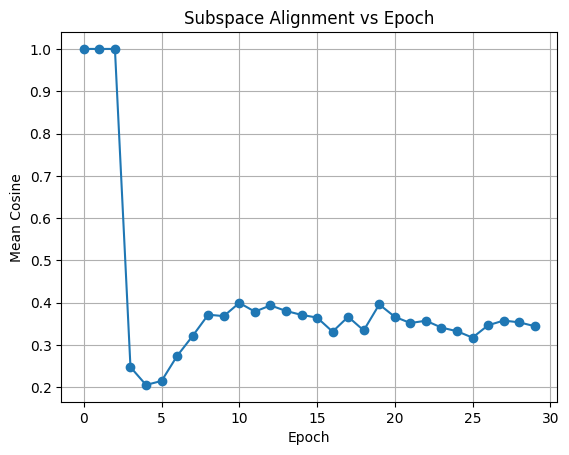

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "efficientnetb0",
    "epochs": 30,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\synthetic_data\NORMAL",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\synthetic_data\PNEUMONIA",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\val_data\NORMAL",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\val_data\PNEUMONIA",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\test_data\NORMAL",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\pneumonia_cxr\test_data\PNEUMONIA",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\pneumonia_cxr_efficientnetb0.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output\pneumonia_cxr_efficientnetb0.png"
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), # Small rotations to mimic slight patient tilt
    transforms.RandomAffine(
        degrees=0, 
        translate=(0.1, 0.1), 
        scale=(0.9, 1.1)
    ), # Zoom and shift
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Mimic different X-ray exposures
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard ImageNet normalization
])

val_test_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], train_transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], train_transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], val_test_transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], val_test_transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], val_test_transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], val_test_transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")


# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()

## ResNet18 Model Skin Lesion Synthetic Data Training


🚀 Epoch 1/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.0000
✅ Saved new best model!

🚀 Epoch 2/30
Alignment: 0.9946
Val Accuracy: 0.5000, Val F1: 0.0000

🚀 Epoch 3/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.0000

🚀 Epoch 4/30
Alignment: 1.0000
Val Accuracy: 0.7500, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 5/30
Alignment: 1.0000
Val Accuracy: 0.7500, Val F1: 0.8000

🚀 Epoch 6/30
Alignment: 1.0000
Val Accuracy: 0.8000, Val F1: 0.7778
✅ Saved new best model!

🚀 Epoch 7/30
Alignment: 1.0000
Val Accuracy: 0.9000, Val F1: 0.8889
✅ Saved new best model!

🚀 Epoch 8/30
Alignment: 1.0000
Val Accuracy: 0.3500, Val F1: 0.4800

🚀 Epoch 9/30
Alignment: 1.0000
Val Accuracy: 0.6500, Val F1: 0.5882

🚀 Epoch 10/30
Alignment: 1.0000
Val Accuracy: 0.9000, Val F1: 0.8889

🚀 Epoch 11/30
Alignment: 1.0000
Val Accuracy: 0.9000, Val F1: 0.9091

🚀 Epoch 12/30
Alignment: 1.0000
Val Accuracy: 0.8500, Val F1: 0.8235

🚀 Epoch 13/30
Alignment: 1.0000
Val Accuracy: 0.8500, Val F1: 0.8235

🚀 

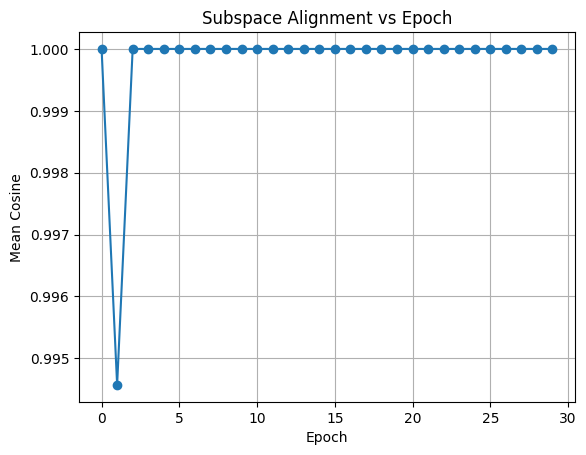

In [4]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "resnet18",
    "epochs": 30,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\final_synthetic_data\healthy",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\final_synthetic_data\lesion",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\val_data\healthy",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\val_data\lesion",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\test_data\healthy",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\test_data\lesion",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\skin_lesion\resnet18.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_skin_lesion_resnet18.png"
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor()
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")

    model_folder, model_filename = os.path.split(CONFIG["output"]["checkpoint_path"])
    model_filename, ext = os.path.splitext(model_folder)
    epoch_wise_model_filename = model_filename + f'_epoch_{epoch}' + '.' + ext
    epoch_wise_model_filepath = os.path.join(model_folder, epoch_wise_model_filename)

    torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
    }, epoch_wise_model_filepath)

# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()

## MobileNetV2 Skin Lesion Synthetic Data Training


🚀 Epoch 1/30
Alignment: 0.9946
Val Accuracy: 0.5000, Val F1: 0.0000
✅ Saved new best model!

🚀 Epoch 2/30
Alignment: 0.9944
Val Accuracy: 0.5000, Val F1: 0.0000

🚀 Epoch 3/30
Alignment: 0.9947
Val Accuracy: 0.5000, Val F1: 0.0000

🚀 Epoch 4/30
Alignment: 0.9947
Val Accuracy: 0.5000, Val F1: 0.0000

🚀 Epoch 5/30
Alignment: 0.9946
Val Accuracy: 0.5000, Val F1: 0.0000

🚀 Epoch 6/30
Alignment: 0.9947
Val Accuracy: 0.5000, Val F1: 0.0000

🚀 Epoch 7/30
Alignment: 0.9946
Val Accuracy: 0.6500, Val F1: 0.4615
✅ Saved new best model!

🚀 Epoch 8/30
Alignment: 0.9945
Val Accuracy: 0.9000, Val F1: 0.9000
✅ Saved new best model!

🚀 Epoch 9/30
Alignment: 0.9946
Val Accuracy: 0.6500, Val F1: 0.5333

🚀 Epoch 10/30
Alignment: 0.9946
Val Accuracy: 0.9000, Val F1: 0.9091

🚀 Epoch 11/30
Alignment: 0.9944
Val Accuracy: 0.8000, Val F1: 0.7500

🚀 Epoch 12/30
Alignment: 0.9949
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 13/30
Alignment: 0.9945
Val Accuracy: 0.9500, Val F1: 0.9524
✅ Saved new best model!

🚀 

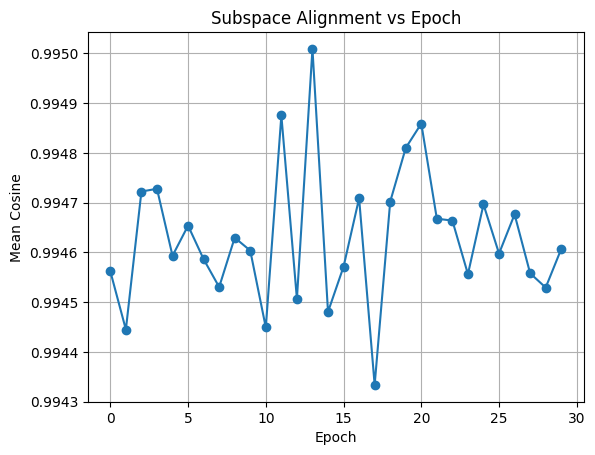

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "mobilenetv2",
    "epochs": 30,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\final_synthetic_data\healthy",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\final_synthetic_data\lesion",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\val_data\healthy",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\val_data\lesion",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\test_data\healthy",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\test_data\lesion",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\skin_lesion\mobilenetv2.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_skin_lesion_mobilenetv2.png"
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor()
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")

    model_folder, model_filename = os.path.split(CONFIG["output"]["checkpoint_path"])
    model_filename, ext = os.path.splitext(model_folder)
    epoch_wise_model_filename = model_filename + f'_epoch_{epoch}' + '.' + ext
    epoch_wise_model_filepath = os.path.join(model_folder, epoch_wise_model_filename)

    torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
    }, epoch_wise_model_filepath)

# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()

## EfficientNetB0 Model Skin Lesion Synthetic Data training


🚀 Epoch 1/30
Alignment: 0.9385
Val Accuracy: 0.5000, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 2/30
Alignment: 0.9380
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 3/30
Alignment: 0.2306
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 4/30
Alignment: 0.1855
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 5/30
Alignment: 0.2086
Val Accuracy: 0.5000, Val F1: 0.0000

🚀 Epoch 6/30
Alignment: 0.2903
Val Accuracy: 0.5000, Val F1: 0.0000

🚀 Epoch 7/30
Alignment: 0.3134
Val Accuracy: 0.9000, Val F1: 0.8889
✅ Saved new best model!

🚀 Epoch 8/30
Alignment: 0.2466
Val Accuracy: 0.9500, Val F1: 0.9524
✅ Saved new best model!

🚀 Epoch 9/30
Alignment: 0.4153
Val Accuracy: 1.0000, Val F1: 1.0000
✅ Saved new best model!

🚀 Epoch 10/30
Alignment: 0.2300
Val Accuracy: 0.9000, Val F1: 0.9091

🚀 Epoch 11/30
Alignment: 0.2972
Val Accuracy: 0.9500, Val F1: 0.9524

🚀 Epoch 12/30
Alignment: 0.4003
Val Accuracy: 0.9500, Val F1: 0.9524

🚀 Epoch 13/30
Alignment: 0.4139
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 

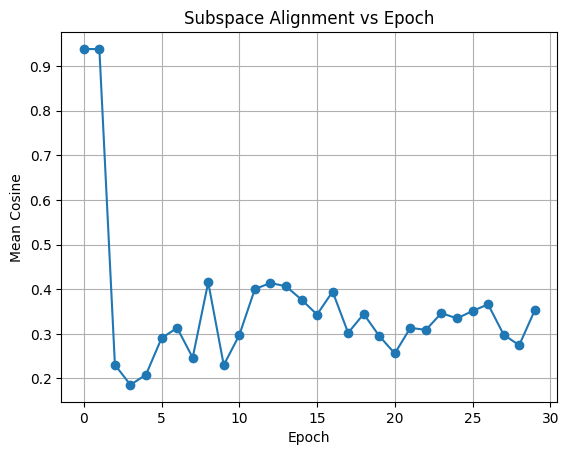

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "efficientnetb0",
    "epochs": 30,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\final_synthetic_data\healthy",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\final_synthetic_data\lesion",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\val_data\healthy",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\val_data\lesion",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\test_data\healthy",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\skin_lesion\test_data\lesion",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\skin_lesion\efficientnetb0.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_skin_lesion_efficientnetb0.png"
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor()
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")

    model_folder, model_filename = os.path.split(CONFIG["output"]["checkpoint_path"])
    model_filename, ext = os.path.splitext(model_folder)
    epoch_wise_model_filename = model_filename + f'_epoch_{epoch}' + '.' + ext
    epoch_wise_model_filepath = os.path.join(model_folder, epoch_wise_model_filename)

    torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
    }, epoch_wise_model_filepath)

# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()

## ResNet-18 Model WaterMark Dataset Synthetic Data Training


🚀 Epoch 1/5
Alignment: 0.8561
Val Accuracy: 0.5000, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 2/5
Alignment: 0.9214
Val Accuracy: 1.0000, Val F1: 1.0000
✅ Saved new best model!

🚀 Epoch 3/5
Alignment: 0.9447
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 4/5
Alignment: 0.9215
Val Accuracy: 0.8500, Val F1: 0.8696

🚀 Epoch 5/5
Alignment: 0.9209
Val Accuracy: 0.8000, Val F1: 0.8333

📊 FINAL RESULTS

--- TRAIN ---
Accuracy: 0.9309
F1 Score: 0.9354

--- TEST ---
Accuracy: 0.9556
F1 Score: 0.9615


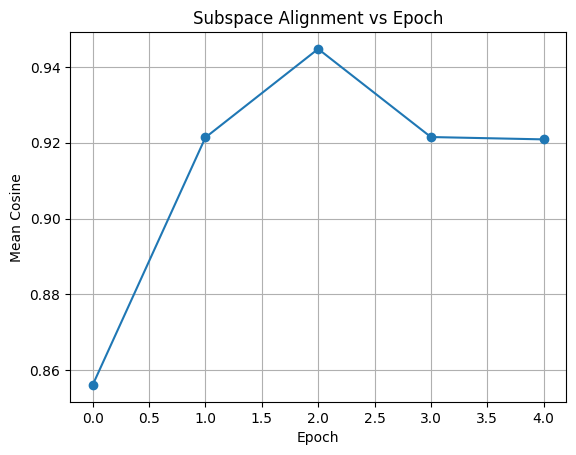

In [6]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "resnet18",
    "epochs": 5,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\synthetic_data\original",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\synthetic_data\watermarked",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\val_data\original",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\val_data\watermarked",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\test_data\original",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\test_data\watermarked",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\watermark_dataset\resnet18.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_watermark_dataset_resnet18.png"
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor()
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")


# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()

## MobileNet-V2 Model WaterMark Dataset Synthetic Data Training


🚀 Epoch 1/5
Alignment: 0.9641
Val Accuracy: 0.5000, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 2/5
Alignment: 0.8982
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 3/5
Alignment: 0.9644
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 4/5
Alignment: 0.3338
Val Accuracy: 0.5500, Val F1: 0.6897
✅ Saved new best model!

🚀 Epoch 5/5
Alignment: 0.4774
Val Accuracy: 1.0000, Val F1: 1.0000
✅ Saved new best model!

📊 FINAL RESULTS

--- TRAIN ---
Accuracy: 0.9814
F1 Score: 0.9818

--- TEST ---
Accuracy: 1.0000
F1 Score: 1.0000


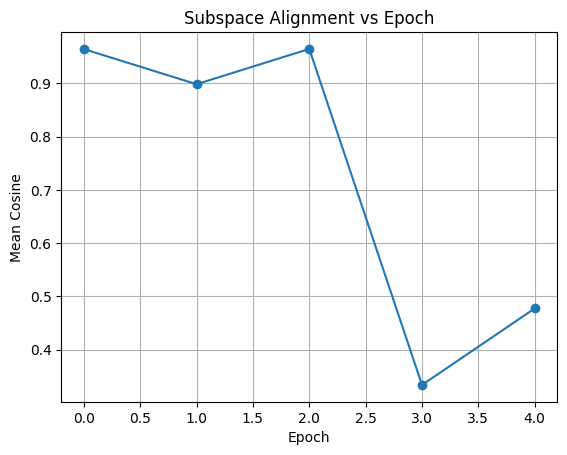

In [7]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "mobilenetv2",
    "epochs": 5,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\synthetic_data\original",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\synthetic_data\watermarked",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\val_data\original",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\val_data\watermarked",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\test_data\original",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\test_data\watermarked",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\watermark_dataset\mobilenetv2.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_watermark_dataset_mobilenetv2.png"
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor()
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")


# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()

## EfficientNet-B0 Model WaterMark Dataset Synthetic Data Training


🚀 Epoch 1/5
Alignment: 0.9725
Val Accuracy: 0.5000, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 2/5
Alignment: 0.1916
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 3/5
Alignment: 0.1893
Val Accuracy: 0.5000, Val F1: 0.6667

🚀 Epoch 4/5
Alignment: 0.1886
Val Accuracy: 1.0000, Val F1: 1.0000
✅ Saved new best model!

🚀 Epoch 5/5
Alignment: 0.2540
Val Accuracy: 1.0000, Val F1: 1.0000

📊 FINAL RESULTS

--- TRAIN ---
Accuracy: 0.9825
F1 Score: 0.9828

--- TEST ---
Accuracy: 1.0000
F1 Score: 1.0000


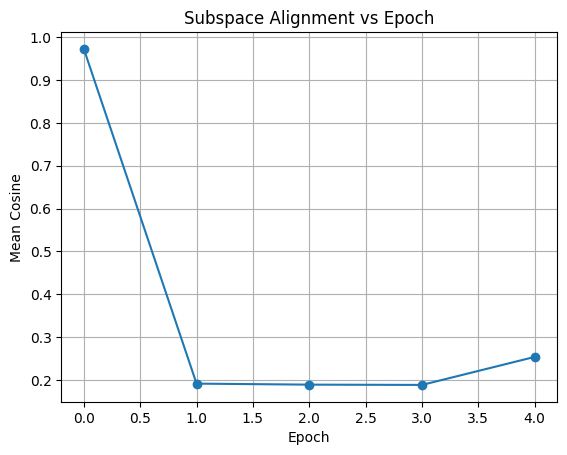

In [9]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "efficientnetb0",
    "epochs": 5,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\synthetic_data\original",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\synthetic_data\watermarked",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\val_data\original",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\val_data\watermarked",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\test_data\original",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\test_data\watermarked",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\watermark_dataset\efficientnetb0.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_watermark_dataset_efficientnetb0.png"
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor()
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")


# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()

# Since test accuracy being 100 percent for few of the models can raise suspicions about overfitting we are trying to evaluate watermark dataset models on other test dataset as well

## ResNet-18 Model Evaluation

Test samples: 726

Loading checkpoint from: C:\Users\97433\Knowing_the_difference\output\watermark_dataset\resnet18.pth
Detected full checkpoint format

===== TEST RESULTS =====
Accuracy : 0.9766
F1 Score : 0.9773
Confusion Matrix:
 [[343  17]
 [  0 366]]

Saved confusion matrix to: C:\Users\97433\Knowing_the_difference\output_watermark_dataset_resnet18.png


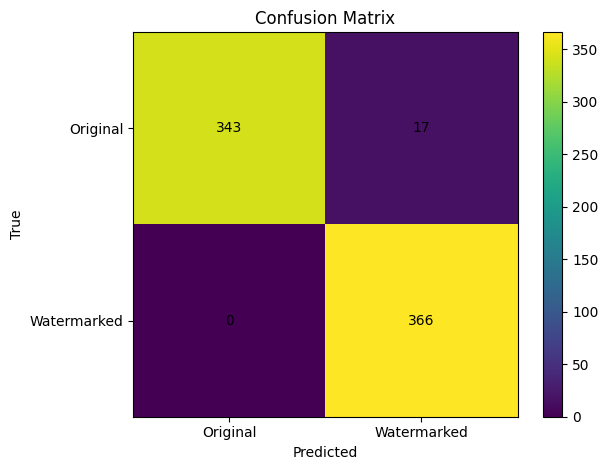

In [11]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "resnet18",
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\test_data2\original",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\test_data2\watermarked",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\watermark_dataset\resnet18.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_watermark_dataset_resnet18.png"
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# DATASET
# =====================================================
class LabeledDataset(Dataset):
    def __init__(self, folder_A, folder_B, transform):
        self.samples = []

        for f in os.listdir(folder_A):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                self.samples.append((os.path.join(folder_A, f), 0))

        for f in os.listdir(folder_B):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                self.samples.append((os.path.join(folder_B, f), 1))

        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except:
            new_idx = random.randint(0, len(self.samples) - 1)
            path, label = self.samples[new_idx]
            img = Image.open(path).convert("RGB")

        return self.transform(img), label

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# TRANSFORMS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
])

# =====================================================
# LOAD DATA
# =====================================================
test_dataset = LabeledDataset(
    CONFIG["data"]["test_A"],
    CONFIG["data"]["test_B"],
    transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False
)

print(f"Test samples: {len(test_dataset)}")

# =====================================================
# LOAD MODEL + CHECKPOINT (FIXED)
# =====================================================
model = load_model(CONFIG["model_name"])

checkpoint_path = CONFIG["output"]["checkpoint_path"]
print(f"\nLoading checkpoint from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=device)

# 🔥 HANDLE BOTH CASES
if "model_state_dict" in checkpoint:
    print("Detected full checkpoint format")
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    print("Detected raw state_dict format")
    model.load_state_dict(checkpoint)

model.eval()

# =====================================================
# EVALUATION
# =====================================================
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# =====================================================
# METRICS
# =====================================================
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("\n===== TEST RESULTS =====")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print("Confusion Matrix:\n", cm)

# =====================================================
# PLOT CONFUSION MATRIX
# =====================================================
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Original", "Watermarked"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

plt.savefig(CONFIG["output"]["plot_path"])
print(f"\nSaved confusion matrix to: {CONFIG['output']['plot_path']}")

## MobileNet-V2 Model Evaluation

Test samples: 726

Loading checkpoint from: C:\Users\97433\Knowing_the_difference\output\watermark_dataset\mobilenetv2.pth
Detected full checkpoint format

===== TEST RESULTS =====
Accuracy : 0.9725
F1 Score : 0.9733
Confusion Matrix:
 [[342  18]
 [  2 364]]

Saved confusion matrix to: C:\Users\97433\Knowing_the_difference\output_watermark_dataset_mobilenetv2.png


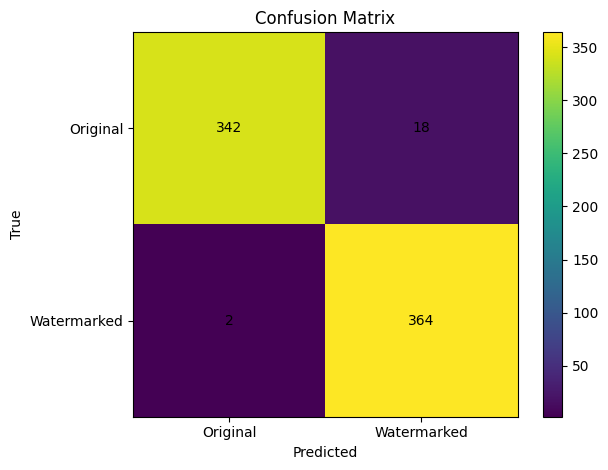

In [12]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "mobilenetv2",
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\test_data2\original",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\test_data2\watermarked",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\watermark_dataset\mobilenetv2.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_watermark_dataset_mobilenetv2.png"
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# DATASET
# =====================================================
class LabeledDataset(Dataset):
    def __init__(self, folder_A, folder_B, transform):
        self.samples = []

        for f in os.listdir(folder_A):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                self.samples.append((os.path.join(folder_A, f), 0))

        for f in os.listdir(folder_B):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                self.samples.append((os.path.join(folder_B, f), 1))

        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except:
            new_idx = random.randint(0, len(self.samples) - 1)
            path, label = self.samples[new_idx]
            img = Image.open(path).convert("RGB")

        return self.transform(img), label

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# TRANSFORMS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
])

# =====================================================
# LOAD DATA
# =====================================================
test_dataset = LabeledDataset(
    CONFIG["data"]["test_A"],
    CONFIG["data"]["test_B"],
    transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False
)

print(f"Test samples: {len(test_dataset)}")

# =====================================================
# LOAD MODEL + CHECKPOINT (FIXED)
# =====================================================
model = load_model(CONFIG["model_name"])

checkpoint_path = CONFIG["output"]["checkpoint_path"]
print(f"\nLoading checkpoint from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=device)

# 🔥 HANDLE BOTH CASES
if "model_state_dict" in checkpoint:
    print("Detected full checkpoint format")
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    print("Detected raw state_dict format")
    model.load_state_dict(checkpoint)

model.eval()

# =====================================================
# EVALUATION
# =====================================================
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# =====================================================
# METRICS
# =====================================================
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("\n===== TEST RESULTS =====")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print("Confusion Matrix:\n", cm)

# =====================================================
# PLOT CONFUSION MATRIX
# =====================================================
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Original", "Watermarked"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

plt.savefig(CONFIG["output"]["plot_path"])
print(f"\nSaved confusion matrix to: {CONFIG['output']['plot_path']}")

## EfficientNet-B0 Model Evaluation

Test samples: 726

Loading checkpoint from: C:\Users\97433\Knowing_the_difference\output\watermark_dataset\efficientnetb0.pth
Detected full checkpoint format

===== TEST RESULTS =====
Accuracy : 0.9917
F1 Score : 0.9918
Confusion Matrix:
 [[357   3]
 [  3 363]]

Saved confusion matrix to: C:\Users\97433\Knowing_the_difference\output_watermark_dataset_efficientnetb0.png


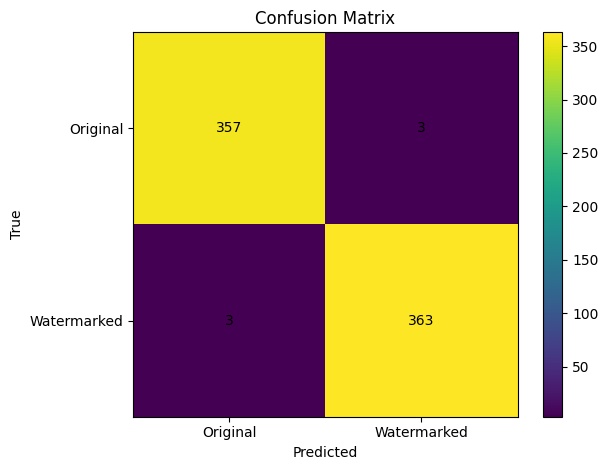

In [13]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "efficientnetb0",
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\test_data2\original",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\watermark_dataset\test_data2\watermarked",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\watermark_dataset\efficientnetb0.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_watermark_dataset_efficientnetb0.png"
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# DATASET
# =====================================================
class LabeledDataset(Dataset):
    def __init__(self, folder_A, folder_B, transform):
        self.samples = []

        for f in os.listdir(folder_A):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                self.samples.append((os.path.join(folder_A, f), 0))

        for f in os.listdir(folder_B):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                self.samples.append((os.path.join(folder_B, f), 1))

        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except:
            new_idx = random.randint(0, len(self.samples) - 1)
            path, label = self.samples[new_idx]
            img = Image.open(path).convert("RGB")

        return self.transform(img), label

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# TRANSFORMS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
])

# =====================================================
# LOAD DATA
# =====================================================
test_dataset = LabeledDataset(
    CONFIG["data"]["test_A"],
    CONFIG["data"]["test_B"],
    transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False
)

print(f"Test samples: {len(test_dataset)}")

# =====================================================
# LOAD MODEL + CHECKPOINT (FIXED)
# =====================================================
model = load_model(CONFIG["model_name"])

checkpoint_path = CONFIG["output"]["checkpoint_path"]
print(f"\nLoading checkpoint from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=device)

# 🔥 HANDLE BOTH CASES
if "model_state_dict" in checkpoint:
    print("Detected full checkpoint format")
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    print("Detected raw state_dict format")
    model.load_state_dict(checkpoint)

model.eval()

# =====================================================
# EVALUATION
# =====================================================
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# =====================================================
# METRICS
# =====================================================
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("\n===== TEST RESULTS =====")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print("Confusion Matrix:\n", cm)

# =====================================================
# PLOT CONFUSION MATRIX
# =====================================================
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Original", "Watermarked"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

plt.savefig(CONFIG["output"]["plot_path"])
print(f"\nSaved confusion matrix to: {CONFIG['output']['plot_path']}")

# ResNet-18 Model Training Horse2Zebra


🚀 Epoch 1/30
Alignment: 0.6033
Val Accuracy: 0.5000, Val F1: 0.0000
✅ Saved new best model!

🚀 Epoch 2/30
Alignment: 0.6041
Val Accuracy: 0.5333, Val F1: 0.1250
✅ Saved new best model!

🚀 Epoch 3/30
Alignment: 0.6049
Val Accuracy: 0.6667, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 4/30
Alignment: 0.6049
Val Accuracy: 0.6333, Val F1: 0.4762

🚀 Epoch 5/30
Alignment: 0.6049
Val Accuracy: 0.5667, Val F1: 0.2353

🚀 Epoch 6/30
Alignment: 0.6048
Val Accuracy: 0.6667, Val F1: 0.5000

🚀 Epoch 7/30
Alignment: 0.6058
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 8/30
Alignment: 0.6054
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 9/30
Alignment: 0.6063
Val Accuracy: 0.4667, Val F1: 0.3846

🚀 Epoch 10/30
Alignment: 0.6054
Val Accuracy: 0.6333, Val F1: 0.6207

🚀 Epoch 11/30
Alignment: 0.6057
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 12/30
Alignment: 0.6048
Val Accuracy: 0.6667, Val F1: 0.5000

🚀 Epoch 13/30
Alignment: 0.6048
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 14/30
Alignment: 0

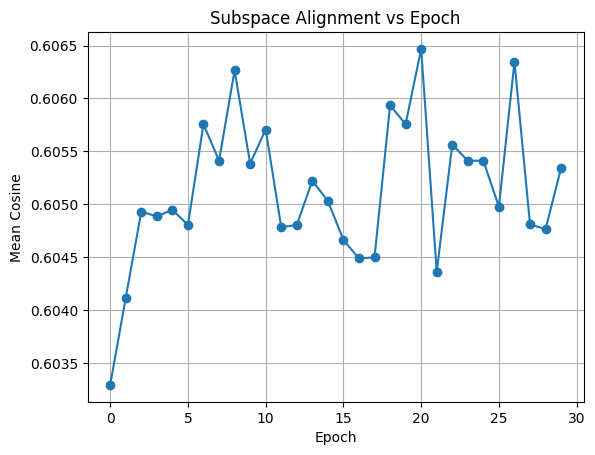

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "resnet18",
    "epochs": 30,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\real_data\horses",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\real_data\zebra",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\val_data\horses",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\val_data\zebra",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\test_data\horses",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\test_data\zebra",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\horses_and_zebra\resnet18.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_horses_and_zebra_resnet18.png"
    }
}

checkpoint_output_dir = os.path.split(CONFIG["output"]["checkpoint_path"])[0]
os.makedirs(checkpoint_output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor()
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")


# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()


🚀 Epoch 1/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.0000
✅ Saved new best model!

🚀 Epoch 2/30
Alignment: 1.0000
Val Accuracy: 0.5000, Val F1: 0.0000

🚀 Epoch 3/30
Alignment: 0.3722
Val Accuracy: 0.6000, Val F1: 0.5385
✅ Saved new best model!

🚀 Epoch 4/30
Alignment: 0.4533
Val Accuracy: 0.5000, Val F1: 0.5455

🚀 Epoch 5/30
Alignment: 0.4526
Val Accuracy: 0.5667, Val F1: 0.2353

🚀 Epoch 6/30
Alignment: 0.6284
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 7/30
Alignment: 0.2972
Val Accuracy: 0.6667, Val F1: 0.6429
✅ Saved new best model!

🚀 Epoch 8/30
Alignment: 0.3551
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 9/30
Alignment: 0.3405
Val Accuracy: 0.6667, Val F1: 0.5000

🚀 Epoch 10/30
Alignment: 0.3147
Val Accuracy: 0.6333, Val F1: 0.4211

🚀 Epoch 11/30
Alignment: 0.3740
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 12/30
Alignment: 0.3166
Val Accuracy: 0.7333, Val F1: 0.6364
✅ Saved new best model!

🚀 Epoch 13/30
Alignment: 0.2474
Val Accuracy: 0.6667, Val F1: 0.5455

🚀 

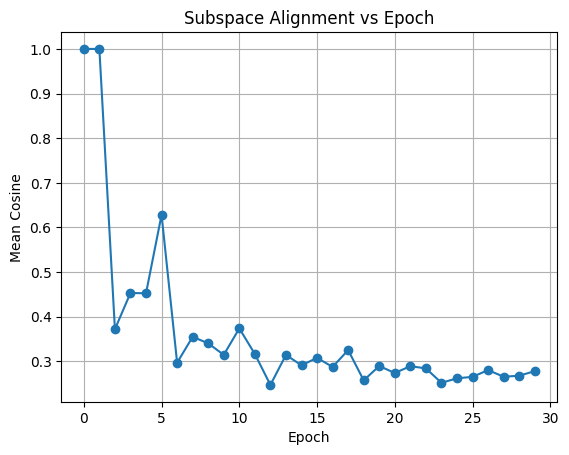

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "mobilenetv2",
    "epochs": 30,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\real_data\horses",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\real_data\zebra",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\val_data\horses",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\val_data\zebra",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\test_data\horses",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\test_data\zebra",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\horses_and_zebra\mobilenetv2.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_horses_and_zebra_mobilenetv2.png"
    }
}

checkpoint_output_dir = os.path.split(CONFIG["output"]["checkpoint_path"])[0]
os.makedirs(checkpoint_output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor()
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")


# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()


🚀 Epoch 1/30
Alignment: 0.9754
Val Accuracy: 0.5000, Val F1: 0.0000
✅ Saved new best model!

🚀 Epoch 2/30
Alignment: 0.2346
Val Accuracy: 0.5667, Val F1: 0.2353
✅ Saved new best model!

🚀 Epoch 3/30
Alignment: 0.1835
Val Accuracy: 0.6000, Val F1: 0.3333
✅ Saved new best model!

🚀 Epoch 4/30
Alignment: 0.2190
Val Accuracy: 0.6000, Val F1: 0.4000

🚀 Epoch 5/30
Alignment: 0.2699
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 6/30
Alignment: 0.2021
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 7/30
Alignment: 0.2440
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 8/30
Alignment: 0.2084
Val Accuracy: 0.6333, Val F1: 0.4211
✅ Saved new best model!

🚀 Epoch 9/30
Alignment: 0.2066
Val Accuracy: 0.6667, Val F1: 0.5000
✅ Saved new best model!

🚀 Epoch 10/30
Alignment: 0.2354
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 11/30
Alignment: 0.2331
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 12/30
Alignment: 0.1573
Val Accuracy: 0.6000, Val F1: 0.3333

🚀 Epoch 13/30
Alignment: 0.2351
Val Accuracy: 0.

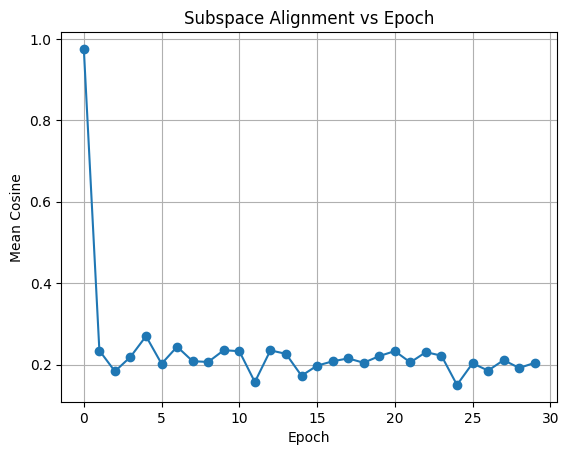

In [3]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "efficientnetb0",
    "epochs": 30,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\real_data\horses",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\real_data\zebra",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\val_data\horses",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\val_data\zebra",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\test_data\horses",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\horses_and_zebra\test_data\zebra",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\horses_and_zebra\efficientnetb0.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_horses_and_zebra_efficientnetb0.png"
    }
}

checkpoint_output_dir = os.path.split(CONFIG["output"]["checkpoint_path"])[0]
os.makedirs(checkpoint_output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor()
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")


# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()


🚀 Epoch 1/10
Alignment: 0.6401
Val Accuracy: 0.9500, Val F1: 0.9524
✅ Saved new best model!

🚀 Epoch 2/10
Alignment: 0.6138
Val Accuracy: 1.0000, Val F1: 1.0000
✅ Saved new best model!

🚀 Epoch 3/10
Alignment: 0.6360
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 4/10
Alignment: 0.6156
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 5/10
Alignment: 0.6479
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 6/10
Alignment: 0.6207
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 7/10
Alignment: 0.6473
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 8/10
Alignment: 0.6462
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 9/10
Alignment: 0.6260
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 10/10
Alignment: 0.6438
Val Accuracy: 0.9000, Val F1: 0.8889

📊 FINAL RESULTS

--- TRAIN ---
Accuracy: 0.9151
F1 Score: 0.9112

--- TEST ---
Accuracy: 0.8785
F1 Score: 0.8649


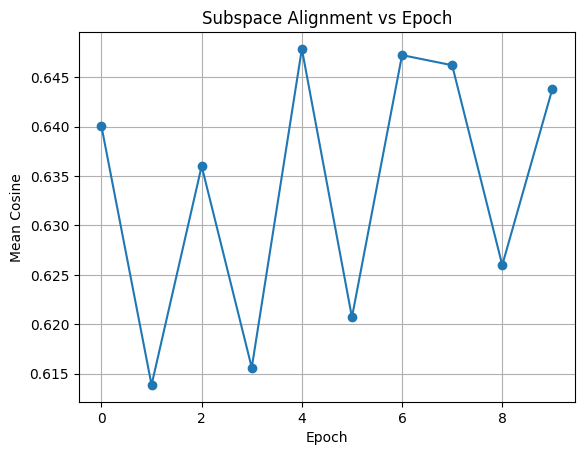

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "resnet18",
    "epochs": 10,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\synthetic_data\apples",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\synthetic_data\oranges",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\val_data\apples",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\val_data\oranges",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\test_data\apples",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\test_data\oranges",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\apples_and_oranges\resnet18.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_apples_and_oranges_resnet18.png"
    }
}

checkpoint_output_dir = os.path.split(CONFIG["output"]["checkpoint_path"])[0]
os.makedirs(checkpoint_output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor()
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")


# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()


🚀 Epoch 1/10
Alignment: 0.9361
Val Accuracy: 0.5000, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 2/10
Alignment: 1.0000
Val Accuracy: 0.6000, Val F1: 0.7143
✅ Saved new best model!

🚀 Epoch 3/10
Alignment: 0.8475
Val Accuracy: 1.0000, Val F1: 1.0000
✅ Saved new best model!

🚀 Epoch 4/10
Alignment: 0.6896
Val Accuracy: 0.9500, Val F1: 0.9524

🚀 Epoch 5/10
Alignment: 0.9933
Val Accuracy: 0.9000, Val F1: 0.9091

🚀 Epoch 6/10
Alignment: 0.6832
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 7/10
Alignment: 0.7263
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 8/10
Alignment: 0.5740
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 9/10
Alignment: 0.5830
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 10/10
Alignment: 0.3803
Val Accuracy: 1.0000, Val F1: 1.0000

📊 FINAL RESULTS

--- TRAIN ---
Accuracy: 0.9814
F1 Score: 0.9812

--- TEST ---
Accuracy: 0.8947
F1 Score: 0.8850


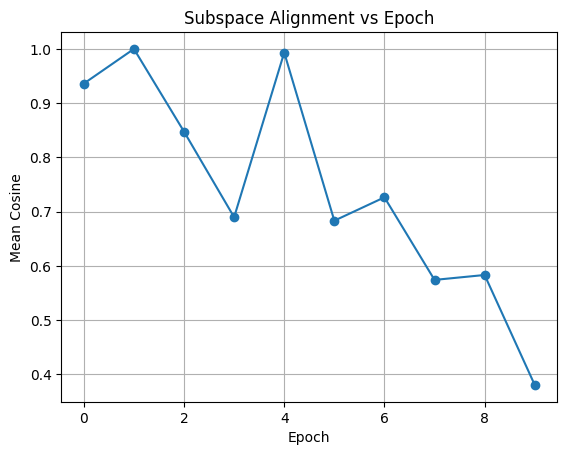

In [3]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "mobilenetv2",
    "epochs": 10,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\synthetic_data\apples",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\synthetic_data\oranges",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\val_data\apples",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\val_data\oranges",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\test_data\apples",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\test_data\oranges",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\apples_and_oranges\mobilenetv2.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_apples_and_oranges_mobilenetv2.png"
    }
}

checkpoint_output_dir = os.path.split(CONFIG["output"]["checkpoint_path"])[0]
os.makedirs(checkpoint_output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor()
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")


# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()


🚀 Epoch 1/10
Alignment: 0.1203
Val Accuracy: 0.5000, Val F1: 0.6667
✅ Saved new best model!

🚀 Epoch 2/10
Alignment: 0.1528
Val Accuracy: 0.8500, Val F1: 0.8696
✅ Saved new best model!

🚀 Epoch 3/10
Alignment: 0.2203
Val Accuracy: 0.9000, Val F1: 0.9091
✅ Saved new best model!

🚀 Epoch 4/10
Alignment: 0.2505
Val Accuracy: 0.9000, Val F1: 0.9091

🚀 Epoch 5/10
Alignment: 0.1758
Val Accuracy: 1.0000, Val F1: 1.0000
✅ Saved new best model!

🚀 Epoch 6/10
Alignment: 0.2087
Val Accuracy: 0.9500, Val F1: 0.9524

🚀 Epoch 7/10
Alignment: 0.2504
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 8/10
Alignment: 0.2331
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 9/10
Alignment: 0.1983
Val Accuracy: 1.0000, Val F1: 1.0000

🚀 Epoch 10/10
Alignment: 0.1875
Val Accuracy: 1.0000, Val F1: 1.0000

📊 FINAL RESULTS

--- TRAIN ---
Accuracy: 0.9839
F1 Score: 0.9840

--- TEST ---
Accuracy: 0.9291
F1 Score: 0.9251


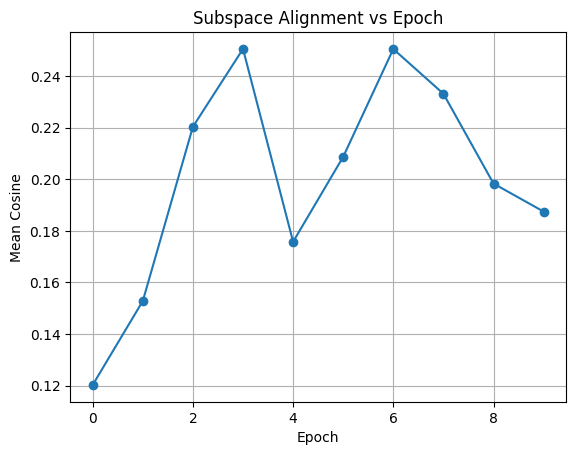

In [4]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# =====================================================
# SET SEED
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =====================================================
# CONFIG
# =====================================================
CONFIG = {
    "model_name": "efficientnetb0",
    "epochs": 10,
    "lr": 1e-3,
    "batch_size": 32,
    "image_size": 224,

    "data": {
        "train_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\synthetic_data\apples",
        "train_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\synthetic_data\oranges",
        "val_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\val_data\apples",
        "val_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\val_data\oranges",
        "test_A": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\test_data\apples",
        "test_B": r"C:\Users\97433\Knowing_the_difference\data\datasets\apples_and_oranges\test_data\oranges",
    },

    "output": {
        "checkpoint_path": r"C:\Users\97433\Knowing_the_difference\output\apples_and_oranges\efficientnetb0.pth",
        "plot_path": r"C:\Users\97433\Knowing_the_difference\output_apples_and_oranges_efficientnetb0.png"
    }
}

checkpoint_output_dir = os.path.split(CONFIG["output"]["checkpoint_path"])[0]
os.makedirs(checkpoint_output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# ROBUST DATASET
# =====================================================
class ImageFolderDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except:
            # fallback: return a random valid image instead
            new_idx = random.randint(0, len(self.paths) - 1)
            img = Image.open(self.paths[new_idx]).convert("RGB")
            return self.transform(img)

# =====================================================
# MODEL
# =====================================================
def load_model(name):
    if name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, 2)

    elif name == "efficientnetb0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    else:
        raise ValueError("Unsupported model")

    return model.to(device)

# =====================================================
# FEATURE EXTRACTOR
# =====================================================
def get_feature_extractor(model, name):
    if name == "resnet18":
        return nn.Sequential(*list(model.children())[:-1])
    elif name == "mobilenetv2":
        return model.features
    elif name == "efficientnetb0":
        return model.features

# =====================================================
# EMBEDDINGS
# =====================================================
def extract_embeddings(model, loader, name):
    model.eval()
    extractor = get_feature_extractor(model, name)

    embeddings = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = extractor(batch)
            feats = torch.flatten(feats, 1)
            embeddings.append(feats.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

# =====================================================
# ROBUST DIFFERENCE (IMPORTANT FIX)
# =====================================================
def compute_difference_matrix(A, B):
    """
    Handles unequal sizes using random pairing
    """
    n = min(len(A), len(B))

    idx_A = np.random.choice(len(A), n, replace=False)
    idx_B = np.random.choice(len(B), n, replace=False)

    return B[idx_B] - A[idx_A]

# =====================================================
# SUBSPACE ALIGNMENT
# =====================================================
def principal_angles(U1, U2):
    M = U1.T @ U2
    _, s, _ = np.linalg.svd(M)
    s = np.clip(s, -1.0, 1.0)
    angles = np.arccos(s)
    return angles, s


def subspace_alignment_score(D1, D2, k=None):
    U1, _, _ = np.linalg.svd(D1, full_matrices=False)
    U2, _, _ = np.linalg.svd(D2, full_matrices=False)

    if k is None:
        k = min(np.linalg.matrix_rank(D1), np.linalg.matrix_rank(D2))

    k = min(k, U1.shape[1], U2.shape[1])

    U1_k = U1[:, :k]
    U2_k = U2[:, :k]

    _, cosines = principal_angles(U1_k, U2_k)

    return float(np.mean(cosines))

# =====================================================
# DATA LOADERS
# =====================================================
transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor()
])

train_A = ImageFolderDataset(CONFIG["data"]["train_A"], transform)
train_B = ImageFolderDataset(CONFIG["data"]["train_B"], transform)

val_A = ImageFolderDataset(CONFIG["data"]["val_A"], transform)
val_B = ImageFolderDataset(CONFIG["data"]["val_B"], transform)

test_A = ImageFolderDataset(CONFIG["data"]["test_A"], transform)
test_B = ImageFolderDataset(CONFIG["data"]["test_B"], transform)

train_loader_A = DataLoader(train_A, batch_size=CONFIG["batch_size"], shuffle=True)
train_loader_B = DataLoader(train_B, batch_size=CONFIG["batch_size"], shuffle=True)

val_loader_A = DataLoader(val_A, batch_size=CONFIG["batch_size"], shuffle=False)
val_loader_B = DataLoader(val_B, batch_size=CONFIG["batch_size"], shuffle=False)

test_loader_A = DataLoader(test_A, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader_B = DataLoader(test_B, batch_size=CONFIG["batch_size"], shuffle=False)

# =====================================================
# FOUNDATION MODEL
# =====================================================
foundation_model = load_model(CONFIG["model_name"])
foundation_model.eval()

emb_A_found = extract_embeddings(foundation_model, train_loader_A, CONFIG["model_name"])
emb_B_found = extract_embeddings(foundation_model, train_loader_B, CONFIG["model_name"])

D_foundation = compute_difference_matrix(emb_A_found, emb_B_found)

# =====================================================
# EVALUATION FUNCTION
# =====================================================
def evaluate(model, loader_A, loader_B):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for loader, label in [(loader_A, 0), (loader_B, 1)]:
            for batch in loader:
                batch = batch.to(device)
                outputs = model(batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend([label] * len(preds))

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, f1

# =====================================================
# TRAINING
# =====================================================
model = load_model(CONFIG["model_name"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0

alignment_history = []

for epoch in range(CONFIG["epochs"]):
    print(f"\n🚀 Epoch {epoch+1}/{CONFIG['epochs']}")

    model.train()

    for batch_A, batch_B in zip(train_loader_A, train_loader_B):
        batch_A = batch_A.to(device)
        batch_B = batch_B.to(device)

        inputs = torch.cat([batch_A, batch_B], dim=0)
        labels = torch.cat([
            torch.zeros(len(batch_A)),
            torch.ones(len(batch_B))
        ]).long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ALIGNMENT TRACKING
    emb_A = extract_embeddings(model, train_loader_A, CONFIG["model_name"])
    emb_B = extract_embeddings(model, train_loader_B, CONFIG["model_name"])

    D_cnn = compute_difference_matrix(emb_A, emb_B)

    score = subspace_alignment_score(D_foundation, D_cnn)
    alignment_history.append(score)

    print(f"Alignment: {score:.4f}")

    # =====================================================
    # VALIDATION CHECKPOINTING
    # =====================================================
    val_acc, val_f1 = evaluate(model, val_loader_A, val_loader_B)

    print(f"Val Accuracy: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'alignment': alignment_history[-1]
        }, CONFIG["output"]["checkpoint_path"])

        print("✅ Saved new best model!")


# =====================================================
# FINAL EVALUATION
# =====================================================
train_acc, train_f1 = evaluate(model, train_loader_A, train_loader_B)
test_acc, test_f1 = evaluate(model, test_loader_A, test_loader_B)

print("\n📊 FINAL RESULTS")

print("\n--- TRAIN ---")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\n--- TEST ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# =====================================================
# PLOT
# =====================================================
plt.figure()
plt.plot(alignment_history, marker='o')
plt.title("Subspace Alignment vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine")
plt.grid()

plt.savefig(CONFIG["output"]["plot_path"])
plt.show()